In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/scaler_case_study/scaler_hashed_for_students.csv")

In [ ]:
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
def clean_text(text):
    if isinstance(text, str):
        return re.sub('[^A-Za-z0-9 ]+', '', text)
    return text

df['company_hash'] = df['company_hash'].apply(clean_text)
df['job_position'] = df['job_position'].apply(clean_text)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153279 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [ ]:
len(df)

205843

In [ ]:
# Makes no difference due to index and job_position having too many nulls
df.drop_duplicates()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0
...,...,...,...,...,...,...,...
205838,206918,kjjnz sul,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,220000,NaN,2019.0
205839,206919,djtokclih,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,500000,NaN,2020.0
205840,206920,kllinswz,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,700000,NaN,2021.0
205841,206921,uiw kjjnslkgnz,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,5100000,NaN,2019.0


# Duplicates Handling

In [ ]:
df = df.drop_duplicates(subset=['company_hash','email_hash','orgyear','ctc','ctc_updated_year'])

In [ ]:
df['email_hash'].nunique()

153443

In [ ]:
len(df)

166861

In [ ]:
email_hash_counts = df['email_hash'].value_counts()
print("Top 10 most frequent email hashes:\n", email_hash_counts.head(10))
print("\nNumber of unique email hashes:", df['email_hash'].nunique())

Top 10 most frequent email hashes:
 email_hash
db84980ad197f8eff08b14a3442ff57f6374ea780f2587b310aac54b6c32ee3a    3
c986600ef19093ce70837408516acac9570566a4b29b554cfb6b744ffbe697d6    3
f50642a5376ef38cfd0366c9f3cc9e6bc24a8e322ea59b17c1ce7943531e6f00    2
22e506818f2b66c966fa4932abe8b6ff8eb05428090e1b344bc94c35f98233f9    2
7f00726d182f514b7b7276df44564b6ffcb37b9bcaf83b71ef7d6a1a6e9a73dc    2
8e4a0ce0407d91c460b7977d13ed03d6497284023eaef736c6e11591216a4c2e    2
05ec7d308b94793ba2e74df99ad365cec503e0c5aefe7e189e09e2dfddd0a42f    2
7f6d981cf243cbfcdf0e1fc6aff4cd3028a6fa30bd1dff6b8a26a1e9bfc77ed9    2
3fca7509086ed61a7e5d7a3448664c259d0f0f134c14a0da65ec47dde9211ac4    2
6b3345fff21b7b5e75867ede01e0db109dd33d3fe0443f6e0a32be030bd0be14    2
Name: count, dtype: int64

Number of unique email hashes: 153443


In [ ]:
top_hashes = email_hash_counts.head(10).index
df[df['email_hash'].isin(top_hashes)] \
    .sort_values(['email_hash', 'ctc_updated_year']) \
    .head(50)

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
39042,39087,bsukfwok,05ec7d308b94793ba2e74df99ad365cec503e0c5aefe7e...,2012.0,939999,FullStack Engineer,2019.0
117754,118066,mknhkow nkgf,05ec7d308b94793ba2e74df99ad365cec503e0c5aefe7e...,2012.0,2500000,NaN,2021.0
38963,39008,msjoi nshswzc,22e506818f2b66c966fa4932abe8b6ff8eb05428090e1b...,2018.0,350000,QA Engineer,2019.0
107262,107514,msjoi nshswzc,22e506818f2b66c966fa4932abe8b6ff8eb05428090e1b...,2018.0,400000,QA Engineer,2020.0
39069,39114,nkofzu widgoi,3fca7509086ed61a7e5d7a3448664c259d0f0f134c14a0...,2012.0,780000,FullStack Engineer,2018.0
145987,146539,jesnsjf suuivkwsiu lkhjdf,3fca7509086ed61a7e5d7a3448664c259d0f0f134c14a0...,2012.0,2500000,Backend Engineer,2021.0
39090,39135,lnzi,6b3345fff21b7b5e75867ede01e0db109dd33d3fe0443f...,2014.0,2100000,Backend Engineer,2019.0
59471,59548,mknhkow,6b3345fff21b7b5e75867ede01e0db109dd33d3fe0443f...,2014.0,5700000,FullStack Engineer,2021.0
38981,39026,zyn,7f00726d182f514b7b7276df44564b6ffcb37b9bcaf83b...,2015.0,1440000,Data Scientist,2019.0
99528,99739,zyn,7f00726d182f514b7b7276df44564b6ffcb37b9bcaf83b...,2015.0,1200000,Data Scientist,2021.0


In [ ]:
user_stats = df.groupby('email_hash').agg(
    orgyear_nunique=('orgyear', 'nunique'),
    n_rows=('email_hash', 'size')
).reset_index()

clean_users = user_stats[user_stats['orgyear_nunique'] == 1]['email_hash']
corrupt_users = user_stats[user_stats['orgyear_nunique'] > 1]['email_hash']

In [ ]:
len(clean_users)

152722

In [ ]:
len(corrupt_users)

643

In [ ]:
df = df[df['email_hash'].isin(clean_users)]

In [ ]:
df= df.sort_values(['email_hash', 'ctc_updated_year', 'ctc']).drop_duplicates(subset='email_hash', keep='last')


In [ ]:
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
84638,84782,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012.0,3500000,Backend Engineer,2019.0
506,506,wotw cstswkn,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013.0,250000,Backend Engineer,2020.0
51568,51626,ijwdh,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,2021.0,1300000,NaN,2019.0
53844,53905,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004.0,2000000,FullStack Engineer,2021.0
138229,138707,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009.0,3400000,NaN,2018.0
...,...,...,...,...,...,...,...
39637,39683,zoslffiu fibwmkoz lkhjdf,fffc254e627e4bd1bc0ed7f01f9aebbba7c3cc56ac914e...,2004.0,3529999,QA Engineer,2019.0
185749,186656,znwokvi,fffcf97db1e9c13898f4eb4cd1c2fe862358480e104535...,2015.0,1600000,NaN,2018.0
148315,148878,uww ckwk tnigkn cznsvzoa fzovslzf,fffe7552892f8ca5fb8647d49ca805b72ea0e9538b6b01...,2014.0,900000,Devops Engineer,2019.0
14106,14115,ulo liojiokwsiu,ffff49f963e4493d8bbc7cc15365423d84a767259f7200...,2020.0,700000,FullStack Engineer,2020.0


# Lesser known companies handling

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152688 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152719 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      119292 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


In [ ]:
df['company_hash'].nunique()

36229

In [ ]:
counts = df['company_hash'].value_counts()
rare_companies = counts[counts < 10].index
df['company_hash'] = df['company_hash'].where(
    ~df['company_hash'].isin(rare_companies),
    'Other'
)

In [ ]:
df['company_hash'].nunique()

1523

In [ ]:
len(df[df['company_hash']=='Other'])

51123

In [ ]:
df['company_hash'].fillna('Other',inplace=True)

/tmp/ipykernel_839/2352006531.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['company_hash'].fillna('Other',inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152722 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152719 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      119292 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


# Imputation

In [ ]:
group_mode = df.groupby(['company_hash', 'orgyear'])['job_position'] \
               .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

In [ ]:
group_mode

company_hash      orgyear
1ht               1994.0             Data Scientist
                  2006.0     Engineering Leadership
                  2008.0                        NaN
                  2011.0                QA Engineer
                  2012.0          Frontend Engineer
                                      ...          
zywozhz uzwmiorf  2015.0           Backend Engineer
                  2016.0           Backend Engineer
                  2017.0           Backend Engineer
                  2018.0                        NaN
                  2019.0           Backend Engineer
Name: job_position, Length: 17008, dtype: object

In [ ]:
df['group_mode'] = df.set_index(['company_hash', 'orgyear']).index.map(group_mode)

In [ ]:
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,group_mode
84638,84782,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012.0,3500000,Backend Engineer,2019.0,Backend Engineer
506,506,Other,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013.0,250000,Backend Engineer,2020.0,Backend Engineer
51568,51626,ijwdh,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,2021.0,1300000,NaN,2019.0,FullStack Engineer
53844,53905,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004.0,2000000,FullStack Engineer,2021.0,FullStack Engineer
138229,138707,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009.0,3400000,NaN,2018.0,Backend Engineer
...,...,...,...,...,...,...,...,...
39637,39683,Other,fffc254e627e4bd1bc0ed7f01f9aebbba7c3cc56ac914e...,2004.0,3529999,QA Engineer,2019.0,Engineering Leadership
185749,186656,Other,fffcf97db1e9c13898f4eb4cd1c2fe862358480e104535...,2015.0,1600000,NaN,2018.0,Backend Engineer
148315,148878,uww ckwk tnigkn cznsvzoa fzovslzf,fffe7552892f8ca5fb8647d49ca805b72ea0e9538b6b01...,2014.0,900000,Devops Engineer,2019.0,Devops Engineer
14106,14115,ulo liojiokwsiu,ffff49f963e4493d8bbc7cc15365423d84a767259f7200...,2020.0,700000,FullStack Engineer,2020.0,Backend Engineer


In [ ]:
df['job_position'] = df['job_position'].fillna(df['group_mode'])
df.drop(columns='group_mode', inplace=True)

In [ ]:
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
84638,84782,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012.0,3500000,Backend Engineer,2019.0
506,506,Other,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013.0,250000,Backend Engineer,2020.0
51568,51626,ijwdh,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,2021.0,1300000,FullStack Engineer,2019.0
53844,53905,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004.0,2000000,FullStack Engineer,2021.0
138229,138707,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009.0,3400000,Backend Engineer,2018.0
...,...,...,...,...,...,...,...
39637,39683,Other,fffc254e627e4bd1bc0ed7f01f9aebbba7c3cc56ac914e...,2004.0,3529999,QA Engineer,2019.0
185749,186656,Other,fffcf97db1e9c13898f4eb4cd1c2fe862358480e104535...,2015.0,1600000,Backend Engineer,2018.0
148315,148878,uww ckwk tnigkn cznsvzoa fzovslzf,fffe7552892f8ca5fb8647d49ca805b72ea0e9538b6b01...,2014.0,900000,Devops Engineer,2019.0
14106,14115,ulo liojiokwsiu,ffff49f963e4493d8bbc7cc15365423d84a767259f7200...,2020.0,700000,FullStack Engineer,2020.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152722 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152719 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      149842 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


In [ ]:
company_mode = df.groupby('company_hash')['job_position'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df['job_position'] = df['job_position'].fillna(
    df['company_hash'].map(company_mode)
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152722 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152719 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      152152 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


In [ ]:
df['job_position'] = df['job_position'].fillna(df['job_position'].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152722 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152719 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      152722 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


In [ ]:
df['orgyear'] = df['orgyear'].fillna(df['orgyear'].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152722 entries, 84638 to 116860
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152722 non-null  int64  
 1   company_hash      152722 non-null  object 
 2   email_hash        152722 non-null  object 
 3   orgyear           152722 non-null  float64
 4   ctc               152722 non-null  int64  
 5   job_position      152722 non-null  object 
 6   ctc_updated_year  152722 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ MB


In [ ]:
df['orgyear'].describe()

,orgyear
count,152722.000000
mean,2014.572747
std,72.694927
min,0.000000
25%,2013.000000
50%,2016.000000
75%,2018.000000
max,20165.000000


In [ ]:
df = df[df['orgyear']>1970]

In [ ]:
# import seaborn as sns

# sns.histplot(df['orgyear'])

In [ ]:
# rough estimate of work experience
df['years_of_experience'] = df['ctc_updated_year'] - df['orgyear']

In [ ]:
df = df[df['years_of_experience'] >= 0]

In [ ]:
len(df)

145753

In [ ]:
df['ctc'].describe()

,ctc
count,1.457530e+05
mean,2.462774e+06
std,1.277486e+07
min,2.000000e+00
25%,5.500000e+05
50%,9.900000e+05
75%,1.700000e+06
max,1.000150e+09


# Outlier Handling

In [ ]:
import seaborn as sns

df[(df['ctc'] < 100000) & (df['years_of_experience'] > 1)]

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience
104249,104488,Other,004307e4e64061f6b94bdac1a190fb59807d3f6e8cdcc0...,2018.0,9700,FullStack Engineer,2020.0,2.0
70406,70505,Other,004475d1956dc8710422acad5760d1a04751044028b5a7...,2012.0,15000,FullStack Engineer,2018.0,6.0
178222,179065,Other,006a520b69e0687df0b0858a8fac33a505213c93635339...,2015.0,37000,Backend Engineer,2018.0,3.0
187716,188639,giirsutlih,0097b0fcb94c2bb2f7ca59cc4493a0fdaa6f646078319b...,2016.0,95000,Backend Engineer,2020.0,4.0
133307,133753,Other,00ab6a257d29e07ba441a91d5bf17dfb9e0d68a98743cf...,2014.0,50000,Backend Engineer,2017.0,3.0
...,...,...,...,...,...,...,...,...
45804,45858,nt znzlwoiuslf,ffb842b12b1b74ffdbfba6e5f4eaf7d41cff2eae1177b9...,2009.0,14000,Android Engineer,2016.0,7.0
133440,133888,tzujklw,ffc54a9b91f0b12ec3c975379c5c3f2c104c600c918c11...,2014.0,2000,Other,2019.0,5.0
139114,139598,bnsjrkow,ffc5bac7cfdf10a84ea26251ea07f655c432a0a2781426...,2001.0,10000,Backend Engineer,2021.0,20.0
142763,143285,subifaf,ffe2d4e5b5c321eb9d45311d66911110c2e5c766bc483d...,2012.0,95000,Backend Engineer,2017.0,5.0


In [ ]:
mask = (df['ctc'] < 100000) & (df['years_of_experience'] > 1)

In [ ]:
group_mean_ctc = df.groupby(
    ['company_hash', 'years_of_experience']
)['ctc'].mean()

In [ ]:
company_mean_ctc = df.groupby('company_hash')['ctc'].mean()

In [ ]:
df['group_ctc_mean'] = df.set_index(['company_hash','years_of_experience']).index.map(group_mean_ctc)
df['company_ctc_mean'] = df['company_hash'].map(company_mean_ctc)

In [ ]:
global_mean_ctc = df['ctc'].mean()

In [ ]:
df.loc[mask, 'ctc'] = (
    df.loc[mask, 'group_ctc_mean']
    .fillna(df.loc[mask, 'company_ctc_mean'])
    .fillna(global_mean_ctc)
)

/tmp/ipykernel_839/380015860.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2399267.63497835 2684580.0235816  2313563.29822599 ...  505000.
 2281852.54273504 2399267.63497835]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'ctc'] = (


In [ ]:
df['ctc'].describe()

,ctc
count,1.457530e+05
mean,2.504052e+06
std,1.277465e+07
min,2.400000e+01
25%,6.000000e+05
50%,1.000000e+06
75%,1.800000e+06
max,1.000150e+09


In [ ]:
df['ctc'].max()

1000150000.0

In [ ]:
df['ctc'].quantile(0.99)

np.float64(20000000.0)

In [ ]:
df['ctc_capped'] = df['ctc'].clip(upper=df['ctc'].quantile(0.99))
df['log_ctc'] = np.log1p(df['ctc_capped'])

In [ ]:
df['log_ctc'].describe()

,log_ctc
count,145753.000000
mean,13.822356
std,0.917232
min,3.218876
25%,13.304687
50%,13.815512
75%,14.403298
max,16.811243


In [ ]:
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_experience,group_ctc_mean,company_ctc_mean,ctc_capped,log_ctc
84638,84782,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012.0,3500000.0,Backend Engineer,2019.0,7.0,3.054773e+06,3.512768e+06,3500000.0,15.068274
506,506,Other,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013.0,250000.0,Backend Engineer,2020.0,7.0,2.489976e+06,2.662287e+06,250000.0,12.429220
53844,53905,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004.0,2000000.0,FullStack Engineer,2021.0,17.0,2.000000e+06,1.809500e+06,2000000.0,14.508658
138229,138707,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009.0,3400000.0,Backend Engineer,2018.0,9.0,3.517030e+06,2.842985e+06,3400000.0,15.039286
113885,114173,wkwk liufdnwkula fzovslzf,0001b94dbb1e85477b07fb6558ead3456c3735893c81f4...,2018.0,450000.0,Database Administrator,2021.0,3.0,2.484194e+06,2.026061e+06,450000.0,13.017005
...,...,...,...,...,...,...,...,...,...,...,...,...
39637,39683,Other,fffc254e627e4bd1bc0ed7f01f9aebbba7c3cc56ac914e...,2004.0,3529999.0,QA Engineer,2019.0,15.0,2.803397e+06,2.662287e+06,3529999.0,15.076808
185749,186656,Other,fffcf97db1e9c13898f4eb4cd1c2fe862358480e104535...,2015.0,1600000.0,Backend Engineer,2018.0,3.0,2.313563e+06,2.662287e+06,1600000.0,14.285515
148315,148878,uww ckwk tnigkn cznsvzoa fzovslzf,fffe7552892f8ca5fb8647d49ca805b72ea0e9538b6b01...,2014.0,900000.0,Devops Engineer,2019.0,5.0,7.166667e+05,1.245000e+06,900000.0,13.710151
14106,14115,ulo liojiokwsiu,ffff49f963e4493d8bbc7cc15365423d84a767259f7200...,2020.0,700000.0,FullStack Engineer,2020.0,0.0,1.083500e+06,1.235012e+06,700000.0,13.458837


In [ ]:
company_mean_ctc = df.groupby('company_hash')['log_ctc'].mean()
job_mean_ctc = df.groupby('job_position')['log_ctc'].mean()

df['company_te'] = df['company_hash'].map(company_mean_ctc)
df['job_te'] = df['job_position'].map(job_mean_ctc)

df['deviation_from_company_mean_ctc'] = (df['log_ctc'] - df['company_te'])
df['deviation_from_position_mean_ctc'] = df['log_ctc'] - df['job_te']

In [ ]:
job_exp_mean = df.groupby('job_position')['years_of_experience'].mean()
df['job_exp_te'] = df['job_position'].map(job_exp_mean)

df['deviation_from_position_experience'] = df['years_of_experience'] - df['job_exp_te']

In [ ]:
df_for_clustering = df[[ 'years_of_experience','log_ctc','deviation_from_company_mean_ctc',
                        'deviation_from_position_mean_ctc', 'deviation_from_position_experience']]

In [ ]:
df_for_clustering

,years_of_experience,log_ctc,deviation_from_company_mean_ctc,deviation_from_position_mean_ctc,deviation_from_position_experience
84638,7.0,15.068274,0.457682,1.144630,2.441583
506,7.0,12.429220,-1.275441,-1.494424,2.441583
53844,17.0,14.508658,0.445545,0.813467,13.374438
138229,9.0,15.039286,0.394397,1.115643,4.441583
113885,3.0,13.017005,-0.205189,-0.750124,-3.373102
...,...,...,...,...,...
39637,15.0,15.076808,1.372147,1.485586,9.342269
185749,3.0,14.285515,0.580854,0.361871,-1.558417
148315,5.0,13.710151,-0.036047,-0.167892,-1.327779
14106,0.0,13.458837,-0.379699,-0.236354,-3.625562


In [ ]:
X = df_for_clustering.copy()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

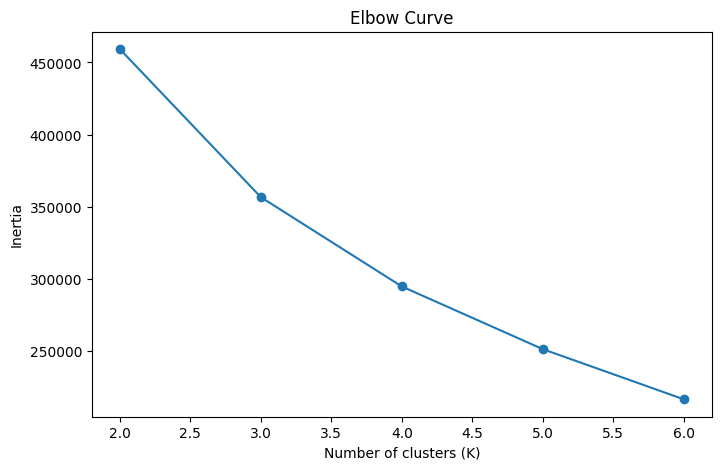

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(
    silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

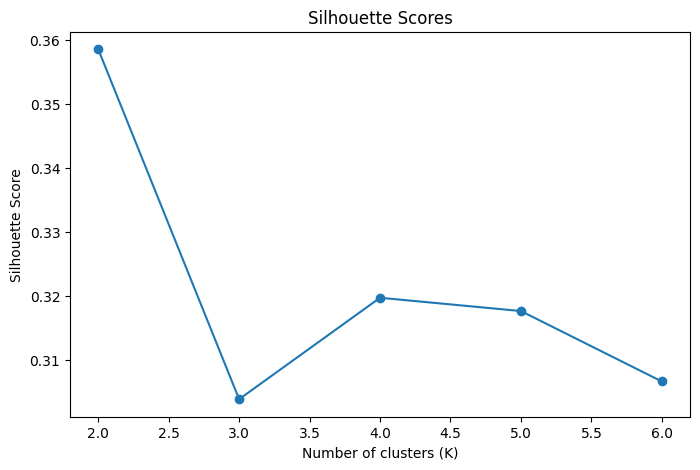

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = (
    df.groupby('cluster')
      .agg({
          'years_of_experience': 'mean',
          'ctc': 'mean',
          'deviation_from_company_mean_ctc': 'mean',
          'deviation_from_position_mean_ctc': 'mean',
          'deviation_from_position_experience': 'mean',
          'cluster': 'count'   # count of rows per cluster
      })
      .rename(columns={'cluster': 'count'})
)

In [ ]:
cluster_summary['company_ratio'] = np.exp(cluster_summary['deviation_from_company_mean_ctc'])
cluster_summary['position_ratio'] = np.exp(cluster_summary['deviation_from_position_mean_ctc'])

In [ ]:
cluster_summary

,years_of_experience,ctc,deviation_from_company_mean_ctc,deviation_from_position_mean_ctc,deviation_from_position_experience,count,company_ratio,position_ratio
cluster,,,,,,,,
0,12.383527,3.151715e+06,0.606206,0.535259,6.368257,20992,1.833463,1.707890
1,3.173419,7.309321e+05,-0.288462,-0.343017,-1.487925,72472,0.749415,0.709626
2,4.005483,2.004428e+05,-1.704622,-1.744088,-0.734298,10578,0.181841,0.174804
3,4.576395,5.843061e+06,0.628405,0.768909,-0.433511,41711,1.874619,2.157411


In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
Z_sample = linkage(X_scaled[sample_idx], method='ward')

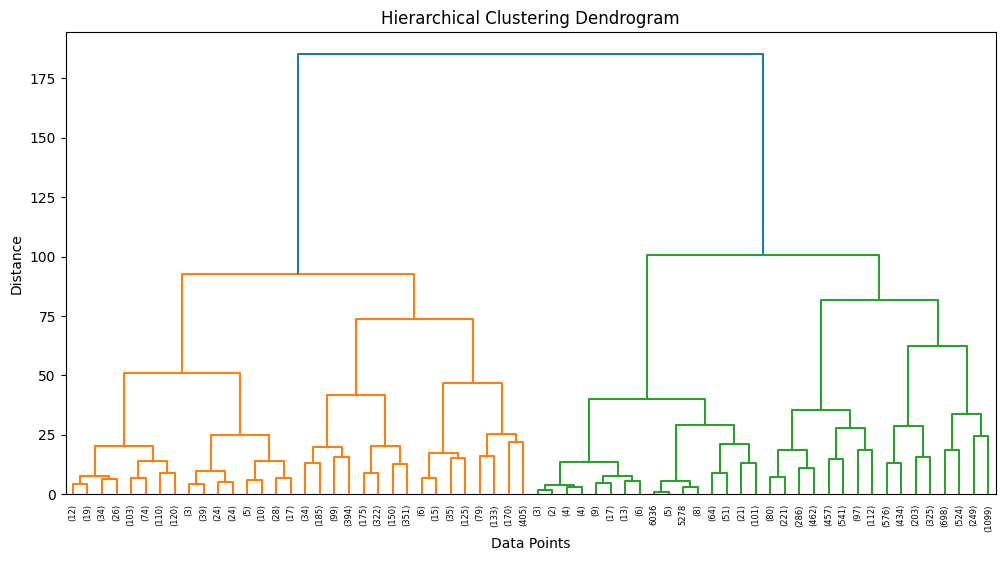

In [ ]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z_sample,
    truncate_mode='level',  # prevents insane plots for large data
    p=5                     # show only top 5 levels
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()